# **Applied Machine Learning for Cyber Security**

## **Notebook 5: Comparative Analysis**
---
This notebook aggregates and compares results from the four prior notebooks:
- Baseline (No SMOTE)
- SMOTE After Train-Test Split
- SMOTE Before Train-Test Split
- Manual Downsampling
---
The goal is to analyze how different balancing techniques affect classification performance.



### **1. Importing Neccessary Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from rich.console import Console
from rich.table import Table
from rich import box
from rich.style import Style
from IPython.display import display, HTML

### **2. Model Performance Metrics Tabular Comparison**

In [2]:
# Load results
results = {
    "Baseline": pd.read_csv("6_results_notebook1.csv", index_col=0),
    "SMOTE After": pd.read_csv("6_results_notebook2.csv", index_col=0),
    "SMOTE Before": pd.read_csv("6_results_notebook3.csv", index_col=0),
    "Downsampling": pd.read_csv("6_results_notebook4.csv", index_col=0)
}

# Combine results
combined = pd.concat(results, names=["Technique", "Model"]).reset_index()
combined = combined.rename(columns={"level_1": "Model"})

# Wider Console
console = Console(width=200)

In [3]:
# Build the Table with extra padding and wide columns
table = Table(
    title="📊 [bold]ML/DL Model Performance Across Techniques[/bold]",
    box=box.SQUARE,
    show_lines=False,
    pad_edge=True  # adds internal padding
)

# Define wider columns
table.add_column("Technique", style="bold cyan", justify="center", no_wrap=True, min_width=30)
table.add_column("Model", style="bold yellow", justify="center", min_width=30)
table.add_column("Accuracy", justify="center", style="green", min_width=25)
table.add_column("Precision", justify="center", style="green", min_width=25)
table.add_column("Recall", justify="center", style="green", min_width=25)
table.add_column("F1 Score", justify="center", style="green", min_width=25)

# Add data rows with section spacers
previous_technique = None
for _, row in combined.iterrows():
    technique = row["Technique"]

    # Add a blank line after each technique block
    if previous_technique is not None and technique != previous_technique:
        table.add_row("", "", "", "", "", "")

    table.add_row(
        f"[cyan]{technique}[/cyan]",
        f"[bold]{row['Model']}[/bold]",
        f"{row['Accuracy']:.4f}",
        f"{row['Precision']:.4f}",
        f"{row['Recall']:.4f}",
        f"{row['F1 Score']:.4f}",
    )

    previous_technique = technique

# Print the final styled table
console.print(table)

                                                                   📊 ML/DL Model Performance Across Techniques                                                                    
┌────────────────────────────────┬────────────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┐
│           Technique            │             Model              │         Accuracy          │         Precision         │          Recall           │         F1 Score          │
├────────────────────────────────┼────────────────────────────────┼───────────────────────────┼───────────────────────────┼───────────────────────────┼───────────────────────────┤
│            Baseline            │      Logistic Regression       │          0.9998           │          0.9998           │          1.0000           │          0.9999           │
│            Baseline            │         Random Forest          │          1.0000           │          1.0000           │          1.0000           │          1.0000           │
│            Baseline            │         MLP Neural Net         │          1.0000           │          1.0000           │          1.0000           │          1.0000           │
│            Baseline            │              LSTM              │          0.9641           │          0.9786           │          0.9805           │          0.9795           │
│            Baseline            │              GRU               │          0.9631           │          0.9701           │          0.9884           │          0.9792           │
│            Baseline            │        Isolation Forest        │          0.9288           │          0.9250           │          1.0000           │          0.9610           │
│                                │                                │                           │                           │                           │                           │
│          SMOTE After           │      Logistic Regression       │          0.9999           │          0.9999           │          1.0000           │          0.9999           │
│          SMOTE After           │         Random Forest          │          1.0000           │          1.0000           │          1.0000           │          1.0000           │
│          SMOTE After           │         MLP Neural Net         │          1.0000           │          1.0000           │          1.0000           │          1.0000           │
│          SMOTE After           │              LSTM              │          0.5738           │          0.5799           │          0.9350           │          0.7158           │
│          SMOTE After           │              GRU               │          0.5730           │          0.6291           │          0.6244           │          0.6267           │
│          SMOTE After           │        Isolation Forest        │          0.9288           │          0.9250           │          1.0000           │          0.9610           │
│                                │                                │                           │                           │                           │                           │
│          SMOTE Before          │      Logistic Regression       │          0.9995           │          0.9989           │          1.0000           │          0.9995           │
│          SMOTE Before          │         Random Forest          │          1.0000           │          1.0000           │          1.0000           │          1.0000           │
│          SMOTE Before          │         MLP Neural Net         │          0.9999           │          0.9999           │          1.0000           │          0.9999           │
│          SMOTE Before          │              LSTM              │          0.9634           │          0.9770           │          0.9814           │          0.9792           │
│          SMOTE Before          │       

### **3. Performance Metrics Slope Graph Comparison**

In [4]:
# Load all results
results = {
    "Baseline": pd.read_csv("6_results_notebook1.csv", index_col=0),
    "SMOTE After": pd.read_csv("6_results_notebook2.csv", index_col=0),
    "SMOTE Before": pd.read_csv("6_results_notebook3.csv", index_col=0),
    "Downsampling": pd.read_csv("6_results_notebook4.csv", index_col=0)
}

# Combine into a single DataFrame
combined = pd.concat(results, names=["Technique", "Model"]).reset_index()
combined = combined.rename(columns={"level_1": "Model"})

# Define metrics and styles
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # For each technique
markers = ["o", "s", "D", "^"]

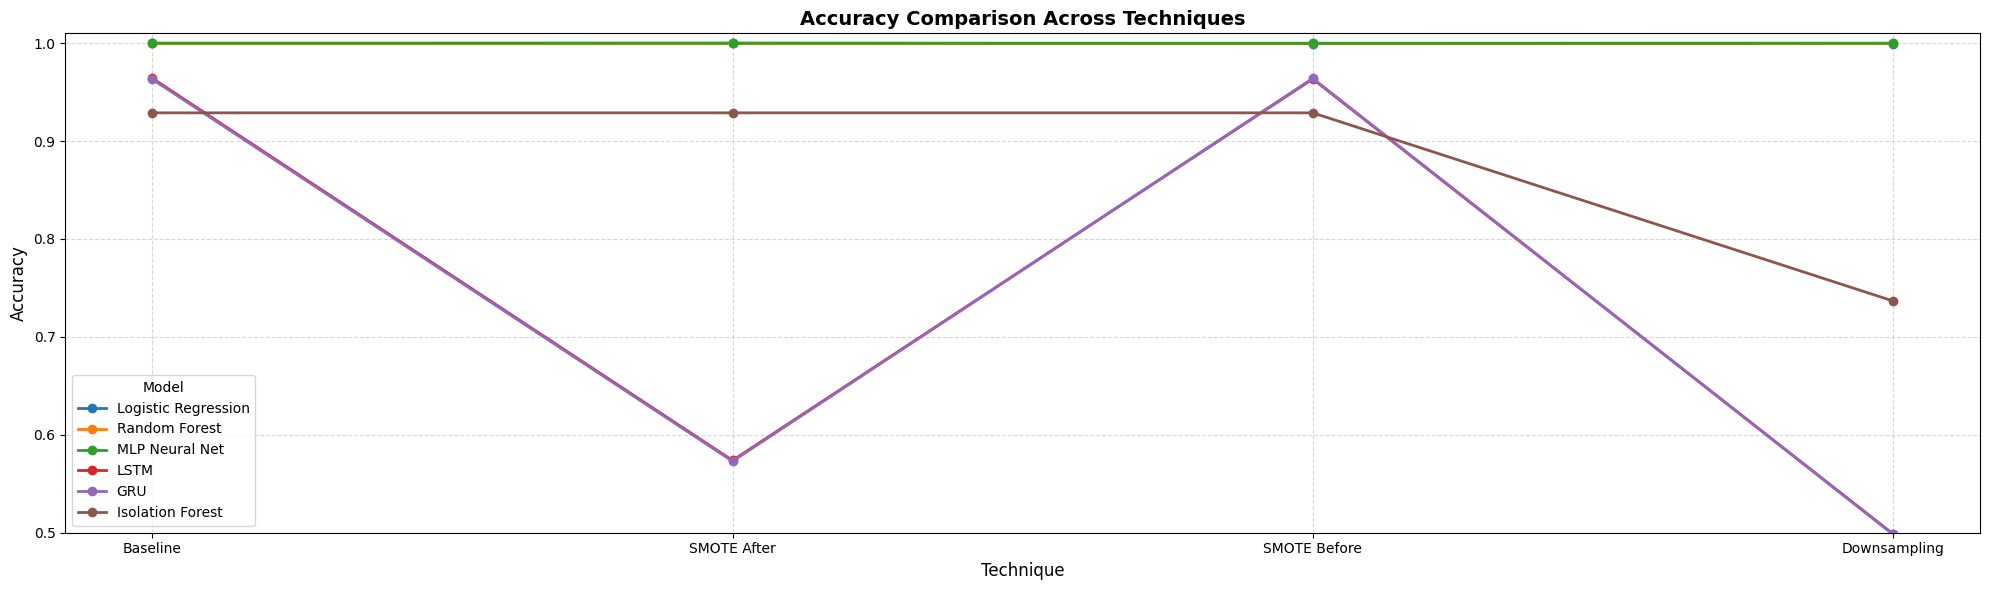

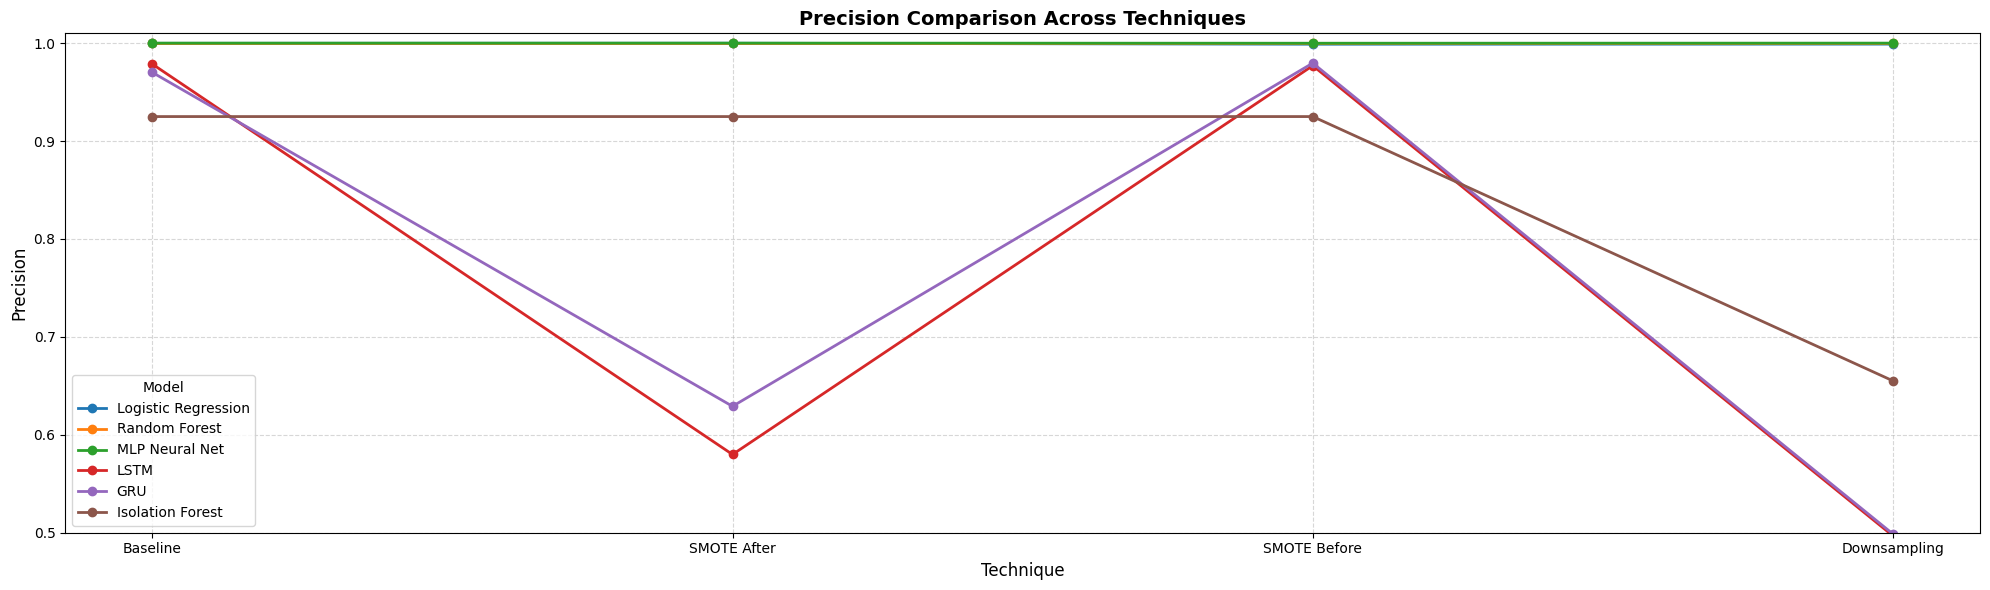

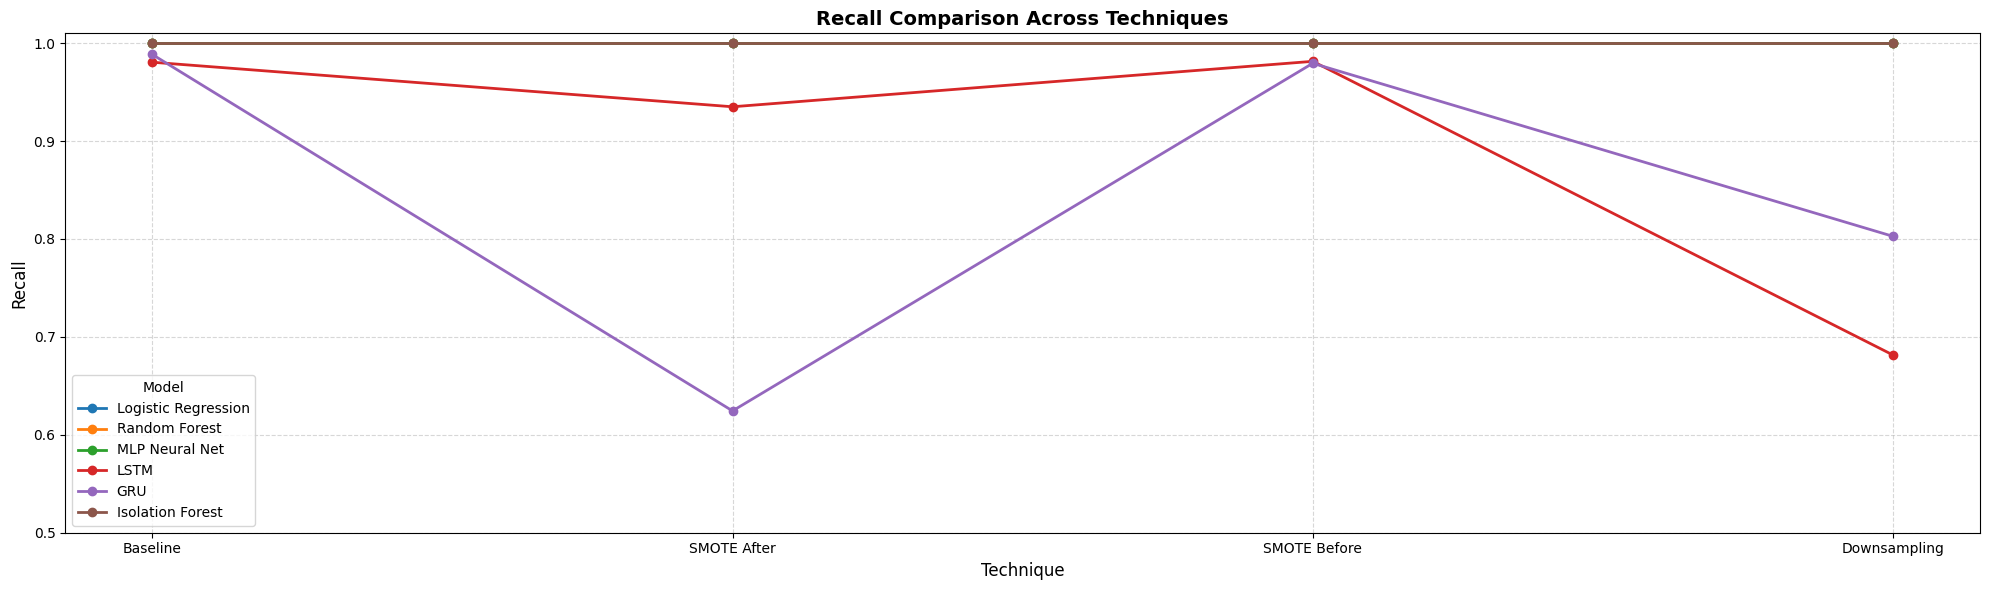

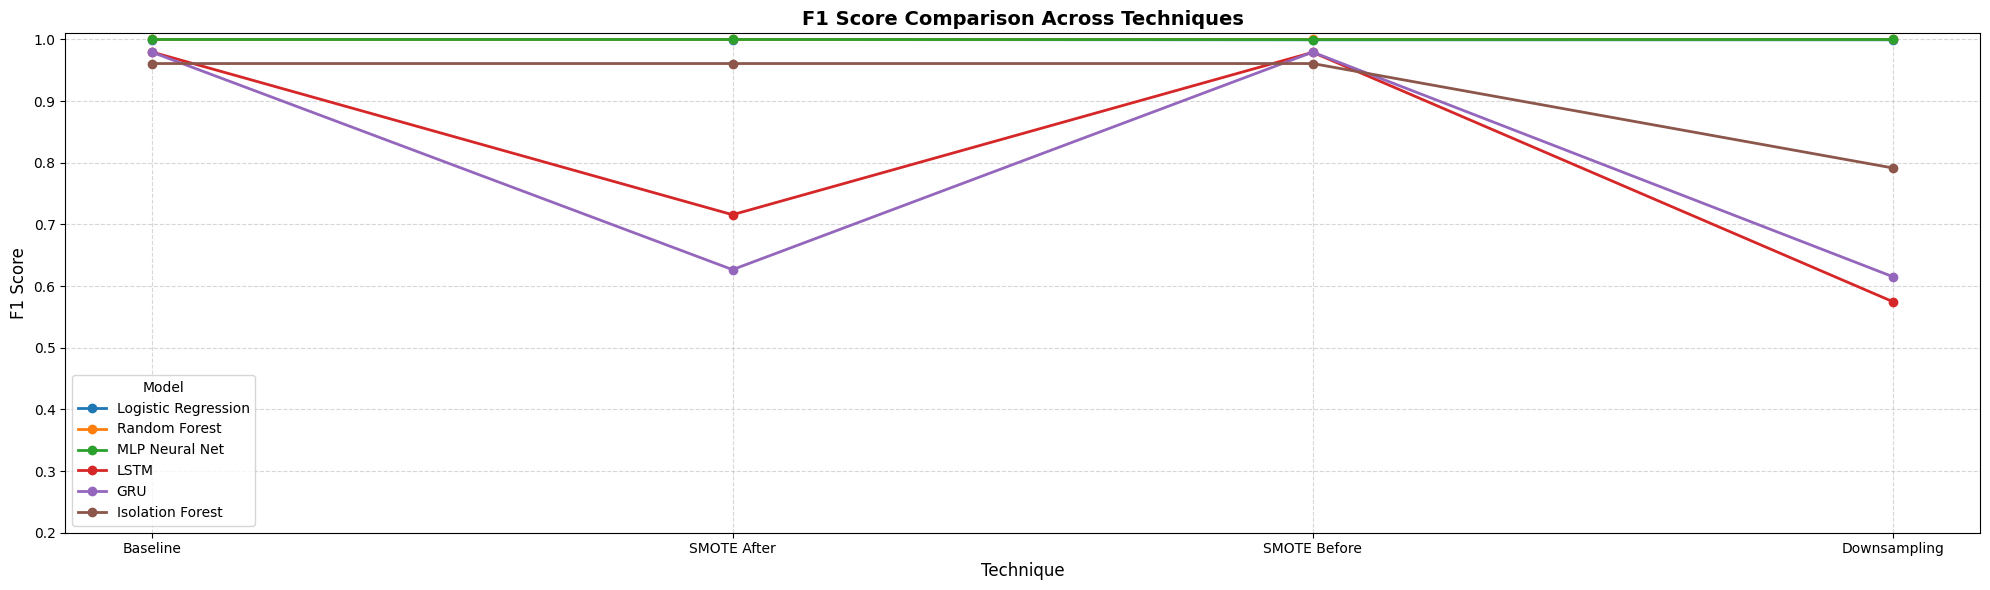

In [5]:
# Plot each metric
for metric in metrics:
    plt.figure(figsize=(20, 6))
    models = combined["Model"].unique()

    for model in models:
        model_data = combined[combined["Model"] == model].set_index("Technique").loc[
            ["Baseline", "SMOTE After", "SMOTE Before", "Downsampling"]
        ]
        plt.plot(
            model_data.index,
            model_data[metric],
            label=model,
            marker='o',
            linewidth=2
        )

    plt.title(f"{metric} Comparison Across Techniques", fontsize=14, weight='bold')
    plt.xlabel("Technique", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.ylim(0.2 if metric == "F1 Score" else 0.5, 1.01)  # For better spread
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Model", fontsize=10)
    plt.tight_layout()
    plt.show()

### **4. Confusion Matrix Comparison**

In [6]:
# Load confusion matrix pickles
paths = {
    "Baseline": "7_confusion_notebook1.pkl",
    "SMOTE After": "7_confusion_notebook2.pkl",
    "SMOTE Before": "7_confusion_notebook3.pkl",
    "Downsampling": "7_confusion_notebook4.pkl"
}

confusion_matrices = {
    technique: pickle.load(open(path, "rb")) for technique, path in paths.items()
}

In [7]:
def plot_confusion_matrices_row(model_key, model_name, confusion_data):
    techniques = list(confusion_data.keys())
    cmaps = ["Blues", "Purples", "Greens", "Oranges"]
    filenames = []

    for i, technique in enumerate(techniques):
        cm = confusion_data[technique][model_key]
        fig, ax = plt.subplots(figsize=(5, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i], ax=ax, cbar=False)
        ax.set_title(technique)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        fname = f"{model_key}_{technique.replace(' ', '_')}.png"
        fig.tight_layout()
        fig.savefig(fname)
        plt.close(fig)
        filenames.append(fname)

    # Display heading
    display(HTML(f"<h2 style='text-align:center;'>📊 {model_name} - Confusion Matrix Comparison</h2>"))

    # Display all 4 images side by side using HTML
    image_html = "".join(
        [f"<img src='{file}' width='330px' style='margin:10px; display:inline-block;'/>" for file in filenames]
    )
    display(HTML(image_html))


In [9]:
plot_confusion_matrices_row("LR", "Logistic Regression", confusion_matrices)
plot_confusion_matrices_row("RF", "Random Forest Classifier", confusion_matrices)
plot_confusion_matrices_row("MLP", "Neural Network (MLP)", confusion_matrices)
plot_confusion_matrices_row("LSTM", "Long Short-Term Memory (LSTM)", confusion_matrices)
plot_confusion_matrices_row("GRU", "Gated Recurrent Units", confusion_matrices)
plot_confusion_matrices_row("ISO", "Isolation Forest", confusion_matrices)